<a href="https://colab.research.google.com/github/ter-sleep/final-project-komputasional/blob/main/notebooks/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install pyswarms -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 3.5 MB/s eta 0:00:00


In [4]:
import pandas as pd

# Lewati 5 baris awal (judul + header), ambil kolom Periode & Data Inflasi
df = pd.read_excel('inflasi.xlsx', skiprows=5, header=None,
                   usecols=[1, 2], names=['tanggal', 'inflasi'])

# Buang baris kosong & baris non-data (pengaman: hanya baris berisi %)
df = df.dropna(subset=['tanggal', 'inflasi'])
df = df[df['inflasi'].astype(str).str.contains('%')].reset_index(drop=True)
print(df.head())  # baris 0 harus: Juni 2026 | 3.34 %

# Bersihkan inflasi: "3.34 %" -> 3.34
df['inflasi'] = (df['inflasi'].astype(str)
                 .str.replace('%', '', regex=False)
                 .str.replace(',', '.', regex=False)
                 .str.strip().astype(float))

# "Juni 2026" -> "2026-06"
bulan_map = {'Januari':'01','Februari':'02','Maret':'03','April':'04',
             'Mei':'05','Juni':'06','Juli':'07','Agustus':'08',
             'September':'09','Oktober':'10','November':'11','Desember':'12'}
df['periode'] = df['tanggal'].astype(str).apply(
    lambda t: f"{t.strip().split()[1]}-{bulan_map[t.strip().split()[0]]}")

# Urutkan kronologis (BI menaruh terbaru di atas)
df = df[['periode', 'inflasi']].sort_values('periode').reset_index(drop=True)
df.to_csv('inflasi.csv', index=False)
print(f"\n✅ inflasi.csv siap — {len(df)} bulan data")
print(df.head(), "\n...\n", df.tail())

         tanggal inflasi
0      Juni 2026  3.34 %
1       Mei 2026  3.08 %
2     April 2026  2.42 %
3     Maret 2026  3.48 %
4  Februari 2026  4.76 %

✅ inflasi.csv siap — 198 bulan data
   periode  inflasi
0  2010-01     3.72
1  2010-02     3.81
2  2010-03     3.43
3  2010-04     3.91
4  2010-05     4.16 
...
      periode  inflasi
193  2026-02     4.76
194  2026-03     3.48
195  2026-04     2.42
196  2026-05     3.08
197  2026-06     3.34


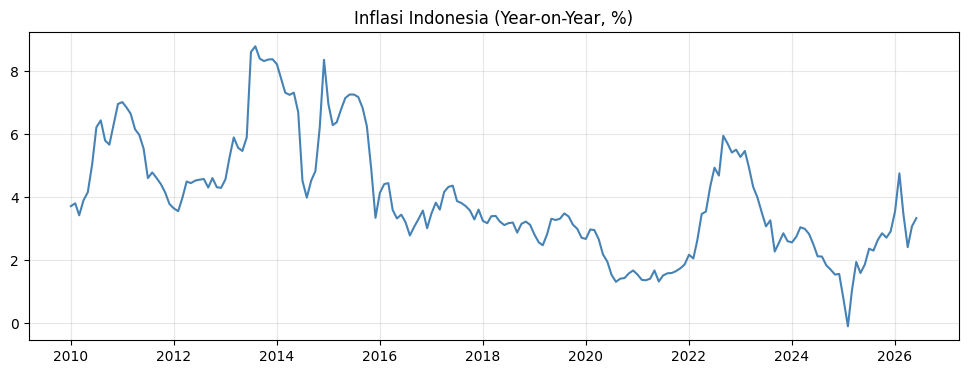

Train: (148, 12), Test: (38, 12)


In [5]:
# ===== 1. PREPROCESSING =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

np.random.seed(42)
N_LAGS = 12

df = pd.read_csv('inflasi.csv')
df['periode'] = pd.to_datetime(df['periode'])
df = df.sort_values('periode').reset_index(drop=True)

# EDA singkat
plt.figure(figsize=(12, 4))
plt.plot(df['periode'], df['inflasi'], color='steelblue')
plt.title('Inflasi Indonesia (Year-on-Year, %)')
plt.grid(alpha=0.3); plt.show()

values = df['inflasi'].values.reshape(-1, 1)
scaler = MinMaxScaler()
scaled = scaler.fit_transform(values).flatten()

X, y = [], []
for i in range(N_LAGS, len(scaled)):
    X.append(scaled[i-N_LAGS:i]); y.append(scaled[i])
X, y = np.array(X), np.array(y)

split = int(len(X) * 0.8)  # split kronologis, tanpa shuffle
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

In [6]:
# ===== 2. BASELINE SVR (SEBELUM OPTIMASI) =====
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluasi(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f'{label} -> RMSE: {rmse:.4f} | MAE: {mae:.4f} | MAPE: {mape:.2f}%')
    return rmse, mae, mape

svr_base = SVR(kernel='rbf')  # default: C=1.0, gamma='scale', epsilon=0.1
svr_base.fit(X_train, y_train)
pred_base = svr_base.predict(X_test)

y_test_asli = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
pred_base_asli = scaler.inverse_transform(pred_base.reshape(-1, 1)).flatten()
hasil_base = evaluasi(y_test_asli, pred_base_asli, 'SVR Baseline')

SVR Baseline -> RMSE: 0.6897 | MAE: 0.5247 | MAPE: 87.01%


2026-07-23 08:03:38,519 - pyswarms.single.global_best - INFO - Optimize for 30 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.7}


Memulai optimasi PSO pada dataset multi-fitur...


pyswarms.single.global_best: 100%|██████████|30/30, best_cost=0.107
2026-07-23 08:03:41,914 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.10687182907566457, best pos: [2.01783724e+02 2.29455069e-01 1.44763245e-01]



Parameter Optimal Baru: C=201.7837, gamma=0.2295, epsilon=0.1448


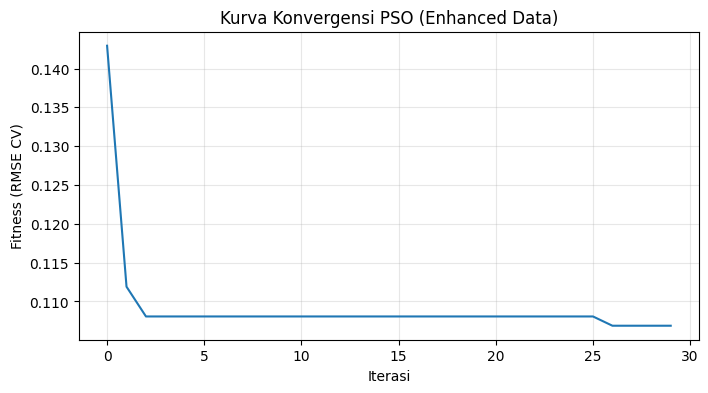

In [7]:
# ===== 3. RE-OPTIMASI PSO (DENGAN ENHANCED DATA) =====
!pip install pyswarms -q
import pyswarms as ps
from sklearn.model_selection import TimeSeriesSplit
import numpy as np
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Batas pencarian parameter [C, gamma, epsilon]
LB = np.array([0.1, 0.0001, 0.0001])
UB = np.array([1000., 10., 0.5])

def fitness_enhanced(particles):
    scores = []
    tscv = TimeSeriesSplit(n_splits=3)
    for p in particles:
        C, gamma, eps = p
        rmses = []
        for tr, va in tscv.split(X_train):
            m = SVR(kernel='rbf', C=C, gamma=gamma, epsilon=eps)
            m.fit(X_train[tr], y_train[tr])
            rmses.append(np.sqrt(mean_squared_error(y_train[va], m.predict(X_train[va]))))
        scores.append(np.mean(rmses))
    return np.array(scores)

options = {'c1': 1.5, 'c2': 1.5, 'w': 0.7}
optimizer = ps.single.GlobalBestPSO(n_particles=20, dimensions=3,
                                    options=options, bounds=(LB, UB))

print("Memulai optimasi PSO pada dataset multi-fitur...")
best_cost, best_pos = optimizer.optimize(fitness_enhanced, iters=30)

C_opt, gamma_opt, eps_opt = best_pos
print(f'\nParameter Optimal Baru: C={C_opt:.4f}, gamma={gamma_opt:.4f}, epsilon={eps_opt:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(optimizer.cost_history)
plt.title('Kurva Konvergensi PSO (Enhanced Data)')
plt.xlabel('Iterasi'); plt.ylabel('Fitness (RMSE CV)')
plt.grid(alpha=0.3); plt.show()


=== PERBANDINGAN METRIK PERFORMA (AKURASI) ===


,Model,RMSE,MAE,MAPE (%),Akurasi (%)
0,SVR Baseline,0.6897,0.5247,87.0107,12.9893
1,SVR-PSO (Optimized),0.7009,0.5539,43.3562,56.6438



=== SAMPEL HASIL PREDIKSI (10 DATA TERAKHIR) ===


,Periode,Aktual,Prediksi Baseline,Prediksi SVR-PSO
28,2025-09,2.65,2.8410,2.2407
29,2025-10,2.86,3.0054,2.4526
30,2025-11,2.72,3.2118,2.4868
31,2025-12,2.92,3.3467,2.3680
32,2026-01,3.55,3.5321,2.4733
33,2026-02,4.76,3.7504,2.9680
34,2026-03,3.48,4.1617,4.2744
35,2026-04,2.42,4.0883,3.4683
36,2026-05,3.08,3.8156,2.8105
37,2026-06,3.34,3.7203,3.6753


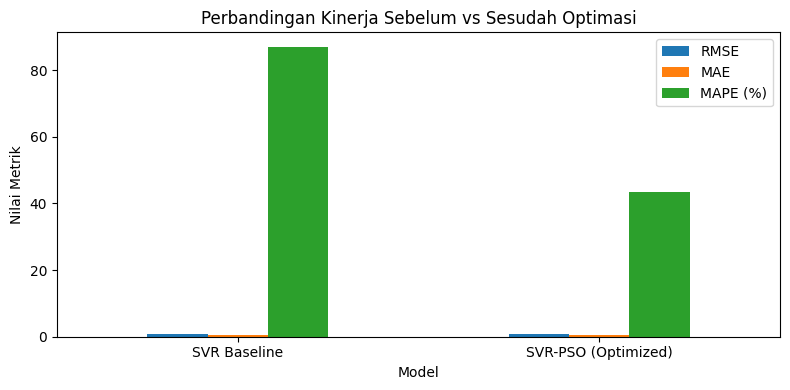

In [8]:
# ===== 4. EVALUASI & TABEL PERBANDINGAN FINAL =====
def evaluasi_final(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    # Menghitung MAPE dengan penanganan pembagian nol
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100
    akurasi = 100 - mape
    return [label, rmse, mae, mape, akurasi]

# 1. Hitung ulang hasil dengan parameter optimal
svr_base.fit(X_train, y_train)
pred_base_asli = scaler.inverse_transform(svr_base.predict(X_test).reshape(-1, 1)).flatten()

svr_pso_final = SVR(kernel='rbf', C=C_opt, gamma=gamma_opt, epsilon=eps_opt)
svr_pso_final.fit(X_train, y_train)
pred_pso_asli = scaler.inverse_transform(svr_pso_final.predict(X_test).reshape(-1, 1)).flatten()
y_test_asli = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# 2. Tabel Metrik (Akurasi)
metrics_data = [
    evaluasi_final(y_test_asli, pred_base_asli, 'SVR Baseline'),
    evaluasi_final(y_test_asli, pred_pso_asli, 'SVR-PSO (Optimized)')
]
tabel_metrik = pd.DataFrame(metrics_data, columns=['Model', 'RMSE', 'MAE', 'MAPE (%)', 'Akurasi (%)'])

print("\n=== PERBANDINGAN METRIK PERFORMA (AKURASI) ===")
display(tabel_metrik.round(4))

# 3. Ambil tanggal yang selaras dengan dimensi X_test
tanggal_test = df['periode'].iloc[-len(y_test_asli):].reset_index(drop=True)

# 4. Tabel Prediksi
tabel_prediksi = pd.DataFrame({
    'Periode': tanggal_test.dt.strftime('%Y-%m'),
    'Aktual': y_test_asli,
    'Prediksi Baseline': pred_base_asli,
    'Prediksi SVR-PSO': pred_pso_asli
})

print("\n=== SAMPEL HASIL PREDIKSI (10 DATA TERAKHIR) ===")
display(tabel_prediksi.tail(10).round(4))

#3Grafik batang perbandingan metrik
tabel_metrik.set_index('Model')[['RMSE', 'MAE', 'MAPE (%)']].plot(kind='bar', figsize=(8, 4), rot=0)
plt.title('Perbandingan Kinerja Sebelum vs Sesudah Optimasi')
plt.ylabel('Nilai Metrik')
plt.tight_layout()
plt.show()

=== HASIL FORECAST 12 BULAN KE DEPAN ===


,Periode,Forecast Baseline,Forecast SVR-PSO
0,2026-07,3.4536,3.2542
1,2026-08,3.2953,2.8727
2,2026-09,3.3084,2.6172
3,2026-10,3.5070,2.4563
4,2026-11,3.6085,2.6759
5,2026-12,3.5332,2.7382
6,2027-01,3.6052,2.7388
7,2027-02,3.7214,2.6838
8,2027-03,3.7551,2.5458
9,2027-04,3.8181,2.5219


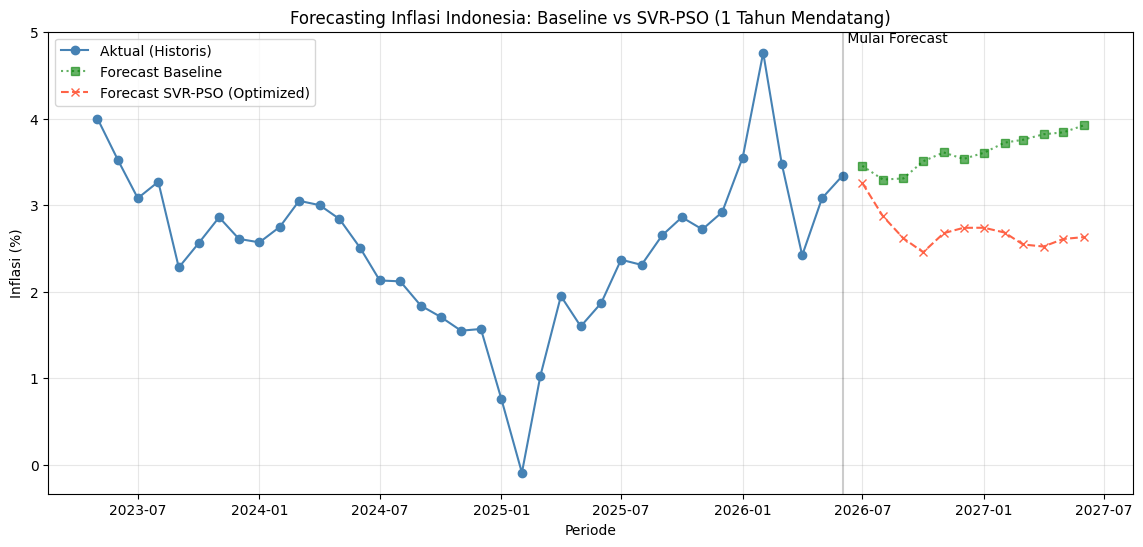

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Persiapan data terakhir untuk forecasting
# Kita mengambil 12 data terakhir (N_LAGS) dari dataset untuk mulai memprediksi bulan depan
last_window = scaled[-N_LAGS:].reshape(1, N_LAGS)

future_months = 12
preds_base_scaled = []
preds_pso_scaled = []

# Salinan window untuk iterasi
curr_window_base = last_window.copy()
curr_window_pso = last_window.copy()

# 2. Iterative Forecasting (Bulan Depan - 1 Tahun ke Depan)
for _ in range(future_months):
    # Prediksi Baseline
    p_base = svr_base.predict(curr_window_base)[0]
    preds_base_scaled.append(p_base)
    curr_window_base = np.append(curr_window_base[:, 1:], [[p_base]], axis=1)

    # Prediksi SVR-PSO
    p_pso = svr_pso_final.predict(curr_window_pso)[0]
    preds_pso_scaled.append(p_pso)
    curr_window_pso = np.append(curr_window_pso[:, 1:], [[p_pso]], axis=1)

# Inverse Transform ke nilai asli
preds_base_future = scaler.inverse_transform(np.array(preds_base_scaled).reshape(-1, 1)).flatten()
preds_pso_future = scaler.inverse_transform(np.array(preds_pso_scaled).reshape(-1, 1)).flatten()

# 3. Buat deret waktu masa depan (Juli 2026 - Juni 2027)
last_date = df['periode'].max()
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=future_months, freq='MS')

# 4. Tabel Hasil Forecast
tabel_forecast = pd.DataFrame({
    'Periode': future_dates.strftime('%Y-%m'),
    'Forecast Baseline': preds_base_future,
    'Forecast SVR-PSO': preds_pso_future
})

print("=== HASIL FORECAST 12 BULAN KE DEPAN ===")
display(tabel_forecast.round(4))

# 5. Visualisasi Gabungan (Aktual + Forecast)
plt.figure(figsize=(14, 6))

# Data Historis (Test Set)
plt.plot(tanggal_test, y_test_asli, label='Aktual (Historis)', color='steelblue', marker='o')

# Forecast Baseline
plt.plot(future_dates, preds_base_future, label='Forecast Baseline', color='green', ls=':', marker='s', alpha=0.6)

# Forecast SVR-PSO
plt.plot(future_dates, preds_pso_future, label='Forecast SVR-PSO (Optimized)', color='tomato', ls='--', marker='x')

# Garis pemisah data aktual & forecast
plt.axvline(x=last_date, color='black', linestyle='-', alpha=0.2)
plt.text(last_date, plt.ylim()[1], ' Mulai Forecast', verticalalignment='top')

plt.title('Forecasting Inflasi Indonesia: Baseline vs SVR-PSO (1 Tahun Mendatang)')
plt.xlabel('Periode')
plt.ylabel('Inflasi (%)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

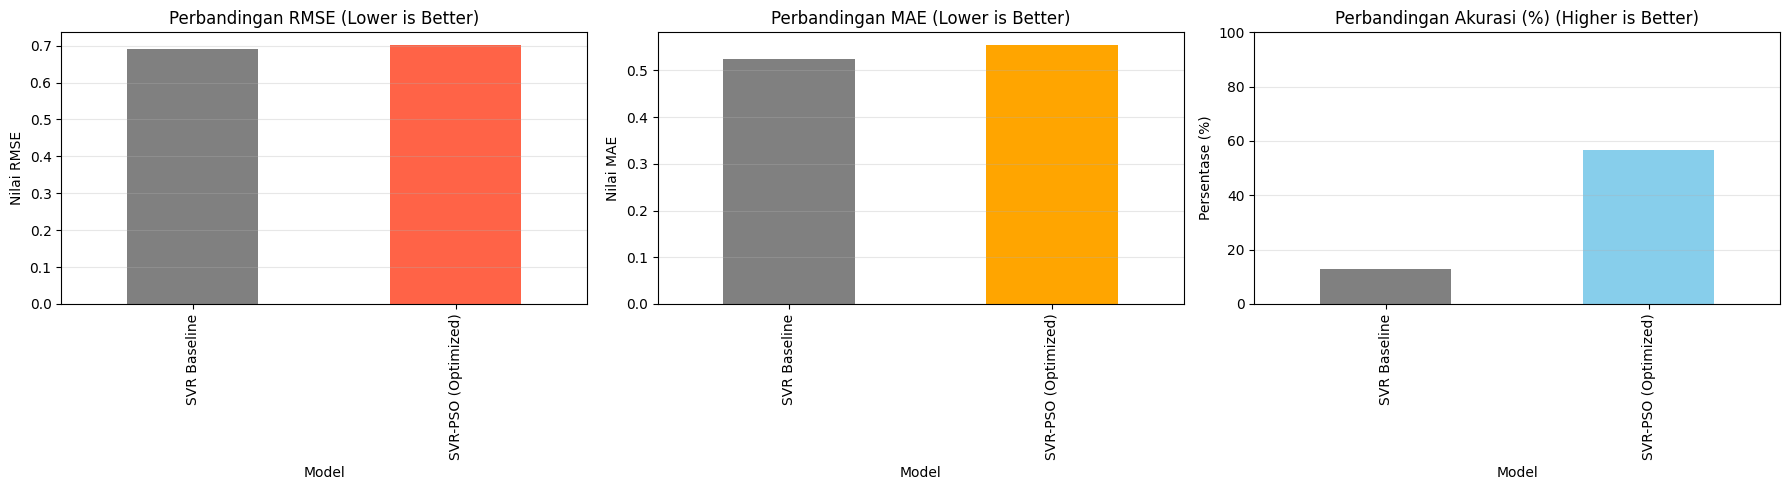

,RMSE,MAE,MAPE (%),Akurasi (%)
Model,,,,
SVR Baseline,0.689666,0.524744,87.010657,12.989343
SVR-PSO (Optimized),0.700870,0.553862,43.356164,56.643836


In [10]:
import matplotlib.pyplot as plt

# Menyiapkan data untuk grafik perbandingan metrik
# Menggunakan variabel 'tabel_metrik' yang sudah dibuat di sel sebelumnya

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Plot RMSE
tabel_metrik.plot(x='Model', y='RMSE', kind='bar', ax=axes[0], color=['gray', 'tomato'], legend=False)
axes[0].set_title('Perbandingan RMSE (Lower is Better)')
axes[0].set_ylabel('Nilai RMSE')
axes[0].grid(axis='y', alpha=0.3)

# 2. Plot MAE
tabel_metrik.plot(x='Model', y='MAE', kind='bar', ax=axes[1], color=['gray', 'orange'], legend=False)
axes[1].set_title('Perbandingan MAE (Lower is Better)')
axes[1].set_ylabel('Nilai MAE')
axes[1].grid(axis='y', alpha=0.3)

# 3. Plot Akurasi (%)
tabel_metrik.plot(x='Model', y='Akurasi (%)', kind='bar', ax=axes[2], color=['gray', 'skyblue'], legend=False)
axes[2].set_title('Perbandingan Akurasi (%) (Higher is Better)')
axes[2].set_ylabel('Persentase (%)')
axes[2].set_ylim(0, 100)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Menampilkan kembali tabel untuk referensi angka
display(tabel_metrik.set_index('Model'))

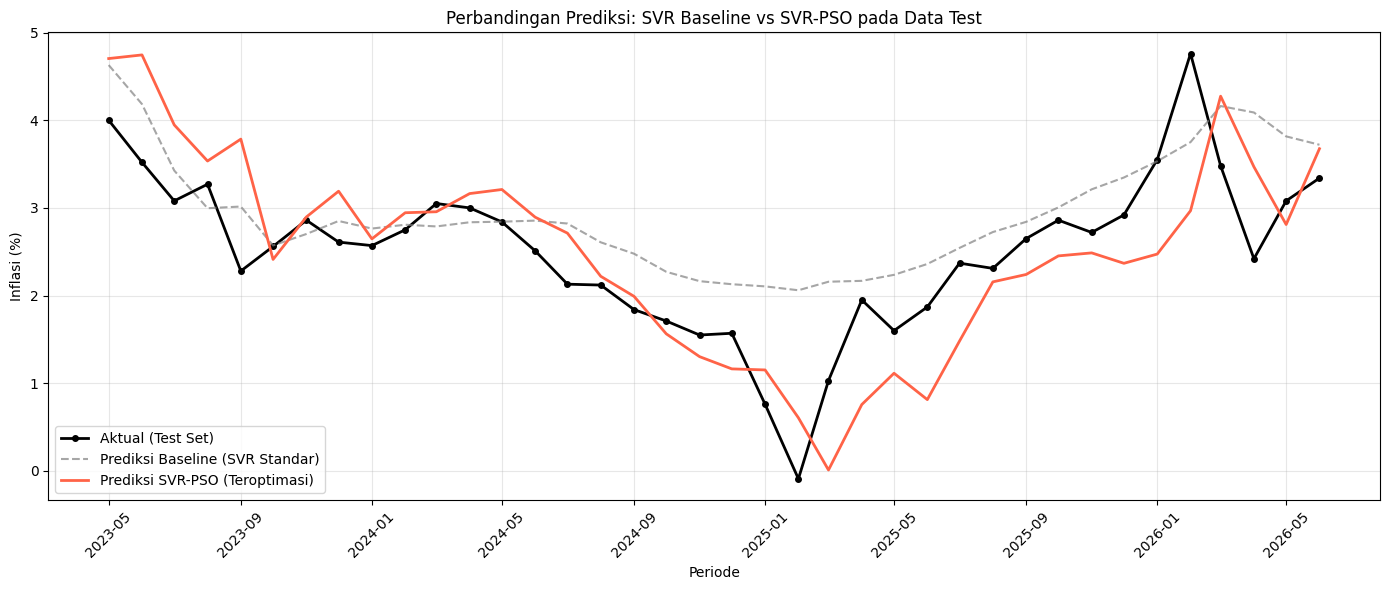

In [11]:
import matplotlib.pyplot as plt

# 1. Grafik Perbandingan Hasil Prediksi pada Data Test
plt.figure(figsize=(14, 6))

# Plot Data Aktual
plt.plot(tanggal_test, y_test_asli, label='Aktual (Test Set)', color='black', linewidth=2, marker='o', markersize=4)

# Plot Prediksi Baseline
plt.plot(tanggal_test, pred_base_asli, label='Prediksi Baseline (SVR Standar)', color='gray', linestyle='--', alpha=0.7)

# Plot Prediksi SVR-PSO
plt.plot(tanggal_test, pred_pso_asli, label='Prediksi SVR-PSO (Teroptimasi)', color='tomato', linewidth=2)

plt.title('Perbandingan Prediksi: SVR Baseline vs SVR-PSO pada Data Test')
plt.xlabel('Periode')
plt.ylabel('Inflasi (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

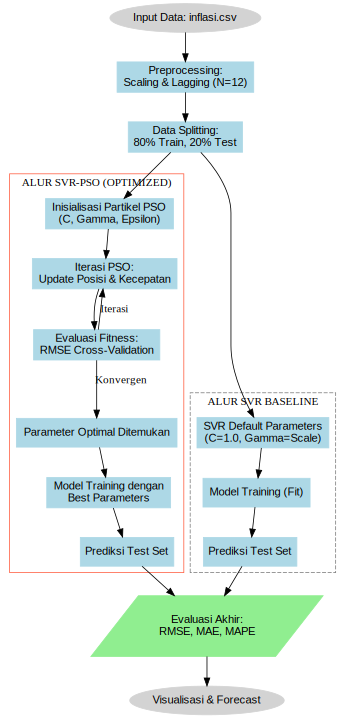

In [13]:
import graphviz

# Membuat diagram alur kerja menggunakan Graphviz
dot = graphviz.Digraph(comment='SVR vs SVR-PSO Workflow', format='png')
dot.attr(rankdir='TB', size='10')

# Pengaturan Gaya Node
dot.attr('node', shape='box', style='filled', color='lightblue', fontname='Arial')

# Nodes Umum
dot.node('START', 'Input Data: inflasi.csv', shape='ellipse', color='lightgrey')
dot.node('PRE', 'Preprocessing:\nScaling & Lagging (N=12)')
dot.node('SPLIT', 'Data Splitting:\n80% Train, 20% Test')

# Subgraph untuk SVR Baseline
with dot.subgraph(name='cluster_0') as c:
    c.attr(label='ALUR SVR BASELINE', color='gray', style='dashed')
    c.node('SVR_B', 'SVR Default Parameters\n(C=1.0, Gamma=Scale)')
    c.node('FIT_B', 'Model Training (Fit)')
    c.node('PRED_B', 'Prediksi Test Set')

# Subgraph untuk SVR-PSO
with dot.subgraph(name='cluster_1') as c:
    c.attr(label='ALUR SVR-PSO (OPTIMIZED)', color='tomato')
    c.node('PSO_INIT', 'Inisialisasi Partikel PSO\n(C, Gamma, Epsilon)')
    c.node('PSO_LOOP', 'Iterasi PSO:\nUpdate Posisi & Kecepatan')
    c.node('FITNESS', 'Evaluasi Fitness:\nRMSE Cross-Validation')
    c.node('PSO_BEST', 'Parameter Optimal Ditemukan')
    c.node('FIT_P', 'Model Training dengan\nBest Parameters')
    c.node('PRED_P', 'Prediksi Test Set')

# Nodes Output
dot.node('EVAL', 'Evaluasi Akhir:\nRMSE, MAE, MAPE', shape='parallelogram', color='lightgreen')
dot.node('END', 'Visualisasi & Forecast', shape='ellipse', color='lightgrey')

# Hubungan antar Node
dot.edge('START', 'PRE')
dot.edge('PRE', 'SPLIT')

# Jalur Baseline
dot.edge('SPLIT', 'SVR_B')
dot.edge('SVR_B', 'FIT_B')
dot.edge('FIT_B', 'PRED_B')
dot.edge('PRED_B', 'EVAL')

# Jalur PSO
dot.edge('SPLIT', 'PSO_INIT')
dot.edge('PSO_INIT', 'PSO_LOOP')
dot.edge('PSO_LOOP', 'FITNESS')
dot.edge('FITNESS', 'PSO_LOOP', label='Iterasi')
dot.edge('FITNESS', 'PSO_BEST', label='Konvergen')
dot.edge('PSO_BEST', 'FIT_P')
dot.edge('FIT_P', 'PRED_P')
dot.edge('PRED_P', 'EVAL')

dot.edge('EVAL', 'END')

display(dot)